In [128]:
%reload_ext autoreload
%autoreload 2

## Analyse spans

In [139]:
%reload_ext autoreload
%autoreload 2

import pandas as pd
from hist_smell.evaluation.near_misses import read_pred_file
from hist_smell.evaluation.near_misses import tokens_to_spans

multi_test_file = 'test-files-mt-all-lang/out-fold-smell-en/folds_2_test.tsv'
multi_pred_file = 'multitask/predictions-mt/predictions-en/2_prediction.tsv'
pred_tokens = list(read_pred_file(multi_pred_file))
test_tokens = list(read_pred_file(multi_test_file))
len(test_tokens), len(pred_tokens)

(21548, 21548)

In [212]:
from hist_smell.evaluation.near_misses import find_overlapping_spans
from hist_smell.evaluation.near_misses import make_overlapping_spans_dataframe

test_dfs = []
pred_dfs = []
overlap_dfs = []

languages = ['de', 'en', 'fr', 'it', 'nl']
for lang in languages:
    for fold in range(0, 5):
        multi_test_file = f'test-files-mt-all-lang/out-fold-smell-{lang}/folds_{fold}_test.tsv'
        multi_hist_file = f'multitask/predictions-mt/predictions-{lang}/{fold}_prediction.tsv'
        multi_cont_file = f'multitask/predictions-mt/predictions-contemporary/predictions-{lang}-contemporary/{fold}_prediction-contemporary.tsv'
        hist_tokens = list(read_pred_file(multi_hist_file))
        cont_tokens = list(read_pred_file(multi_cont_file))
        test_tokens = list(read_pred_file(multi_test_file))
        
        cont_spans = tokens_to_spans(cont_tokens)
        hist_spans = tokens_to_spans(hist_tokens)
        test_spans = tokens_to_spans(test_tokens)
        
        test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
        cont_df = pd.DataFrame([ps.__dict__ for ps in cont_spans])
        hist_df = pd.DataFrame([ps.__dict__ for ps in hist_spans])
        test_df['lang'] = lang
        test_df['fold'] = fold
        cont_df['lang'] = lang
        cont_df['fold'] = fold
        cont_df['model_type'] = 'contemporary'
        hist_df['lang'] = lang
        hist_df['fold'] = fold
        hist_df['model_type'] = 'historical'
        test_dfs.append(test_df)
        pred_dfs.extend([cont_df, hist_df])

        overlapping_spans_cont = find_overlapping_spans(test_spans, cont_spans)
        overlap_df = make_overlapping_spans_dataframe(overlapping_spans_cont)
        overlap_df['lang'] = lang
        overlap_df['fold'] = fold
        overlap_df['model_type'] = 'contemporary'
        overlap_dfs.append(overlap_df)

        overlapping_spans_hist = find_overlapping_spans(test_spans, hist_spans)
        overlap_df = make_overlapping_spans_dataframe(overlapping_spans_hist)
        overlap_df['lang'] = lang
        overlap_df['fold'] = fold
        overlap_df['model_type'] = 'historical'
        overlap_dfs.append(overlap_df)

overlap_df = pd.concat(overlap_dfs)

test_df = pd.concat(test_dfs)
pred_df = pd.concat(pred_dfs)
test_df.shape, pred_df.shape

((20927, 8), (36445, 9))

In [141]:
test_df['span_length'] = test_df.apply(lambda row: row['end'] - row['start'], axis=1)
pred_df['span_length'] = pred_df.apply(lambda row: row['end'] - row['start'], axis=1)


In [142]:
test_df


,text_id,sent_idx,start,end,text,label,lang,fold,span_length
0,HOUSEHOLD_RECIPES_046G_1717_Peter_Pomet_Der_au...,4,79,80,riechen,Smell_Word,de,0,1
1,HOUSEHOLD_RECIPES_046G_1717_Peter_Pomet_Der_au...,4,88,89,Geruch,Smell_Word,de,0,1
2,HOUSEHOLD_RECIPES_046G_1717_Peter_Pomet_Der_au...,2,26,27,Geruch,Smell_Word,de,0,1
3,HOUSEHOLD_RECIPES_046G_1717_Peter_Pomet_Der_au...,4,64,65,Geruch,Smell_Word,de,0,1
4,HOUSEHOLD_RECIPES_046G_1717_Peter_Pomet_Der_au...,5,35,36,riecht,Smell_Word,de,0,1
...,...,...,...,...,...,...,...,...,...
1282,NL_HOUS_potentially_smelly_passages_1177,9,1,3,Oud zynde,Circumstances,nl,4,2
1283,NL_HOUS_potentially_smelly_passages_1177,10,1,3,Door ouderdom,Circumstances,nl,4,2
1284,NL_HOUS_potentially_smelly_passages_1402,6,1,6,Om de lucht te zuiveren,Circumstances,nl,4,5
1285,NL_HOUS_potentially_smelly_passages_1402,10,1,11,Om ’ t Vertrek eens Zieken op een aangename wyze,Circumstances,nl,4,10


In [143]:
test_df.groupby(['lang', 'label']).span_length.describe()

count      mean        std  min  25%  50%    75%    max
lang label                                                                   
de   Circumstances    214.0  7.280374  10.690081  1.0  3.0  5.0   8.00  128.0
     Effect           327.0  5.602446   4.911586  1.0  2.0  4.0   8.00   44.0
     Evoked_Odorant   214.0  2.710280   3.241484  1.0  1.0  2.0   3.00   33.0
     Location         177.0  3.485876   2.898094  1.0  2.0  3.0   4.00   29.0
     Odour_Carrier    113.0  1.672566   1.129495  1.0  1.0  1.0   2.00    6.0
     Perceiver        260.0  1.638462   2.058990  1.0  1.0  1.0   2.00   23.0
     Quality          849.0  1.664311   1.133396  1.0  1.0  1.0   2.00    8.0
     Smell_Source    1393.0  1.986360   2.376359  1.0  1.0  1.0   2.00   39.0
     Smell_Word      1453.0  1.086029   0.415146  1.0  1.0  1.0   1.00    5.0
     Time             115.0  3.095652   2.402389  1.0  1.0  3.0   4.00   14.0
en   Circumstances    178.0  6.348315   4.745741  1.0  3.0  5.0   8.00   41.0
     Effect           116.0  6.594828   5.117707  1.0  3.0  5.0   8.00   38.0
     Evoked_Odorant    58.0  4.068966   2.574245  1.0  2.0  3.0   6.00   11.0
     Location         215.0  3.804651   2.323986  1.0  2.0  3.0   5.00   14.0
     Odour_Carrier    232.0  2.086207   1.383696  1.0  1.0  2.0   3.00   14.0
     Perceiver        310.0  2.103226   1.750355  1.0  1.0  1.0   3.00   12.0
     Quality          875.0  1.461714   0.965934  1.0  1.0  1.0   2.00   14.0
     Smell_Source    1172.0  2.082765   1.613080  1.0  1.0  1.0   3.00   15.0
     Smell_Word      1263.0  1.027712   0.287111  1.0  1.0  1.0   1.00    8.0
     Time              97.0  3.010309   1.997367  1.0  1.0  3.0   4.00    9.0
fr   Circumstances     83.0  5.024096   3.838114  1.0  2.0  4.0   6.00   25.0
     Effect            31.0  4.161290   2.672038  1.0  1.0  4.0   6.00   12.0
     Evoked_Odorant    42.0  1.690476   1.115043  1.0  1.0  1.0   2.00    6.0
     Location         121.0  2.570248   3.434692  1.0  1.0  2.0   3.00   34.0
     Odour_Carrier    107.0  1.224299   0.768586  1.0  1.0  1.0   1.00    7.0
     Perceiver        131.0  1.519084   1.172447  1.0  1.0  1.0   1.00    8.0
     Quality          307.0  1.400651   0.996267  1.0  1.0  1.0   1.00    7.0
     Smell_Source     556.0  1.658273   1.557933  1.0  1.0  1.0   2.00   24.0
     Smell_Word       527.0  1.015180   0.203947  1.0  1.0  1.0   1.00    5.0
     Time              43.0  3.232558   2.180402  1.0  1.0  3.0   4.00   11.0
it   Circumstances    147.0  7.585034   6.312462  1.0  3.0  6.0   9.00   38.0
     Effect            53.0  6.245283   4.582180  2.0  4.0  5.0   7.00   32.0
     Evoked_Odorant    47.0  4.234043   2.647499  2.0  2.5  3.0   5.00   16.0
     Location         122.0  3.647541   2.032472  1.0  2.0  3.0   5.00   12.0
     Odour_Carrier    165.0  2.187879   1.247377  1.0  1.0  2.0   3.00    8.0
     Perceiver        118.0  1.720339   1.232644  1.0  1.0  1.0   2.00    9.0
     Quality          554.0  1.212996   0.525767  1.0  1.0  1.0   1.00    6.0
     Smell_Source     787.0  2.529860   1.780602  1.0  1.0  2.0   3.00   16.0
     Smell_Word      1064.0  1.006579   0.080881  1.0  1.0  1.0   1.00    2.0
     Time              93.0  3.376344   2.536319  1.0  2.0  3.0   4.00   15.0
nl   Circumstances    418.0  7.385167   8.080973  1.0  2.0  5.0   9.75   71.0
     Effect           250.0  7.808000   7.531669  1.0  3.0  5.0  10.00   44.0
     Evoked_Odorant   216.0  3.800926   3.339990  1.0  2.0  3.0   5.00   24.0
     Location         250.0  3.460000   2.673761  1.0  2.0  3.0   4.00   19.0
     Odour_Carrier    329.0  2.121581   1.661193  1.0  1.0  2.0   2.00   11.0
     Perceiver        317.0  1.605678   1.066922  1.0  1.0  1.0   2.00   11.0
     Quality          787.0  1.203304   0.578969  1.0  1.0  1.0   1.00    7.0
     Smell_Source    1824.0  2.023026   1.971969  1.0  1.0  1.0   2.00   23.0
     Smell_Word      1692.0  1.019504   0.182558  1.0  1.0  1.0   1.00    4.0
     Time             115.0  3.304348   2.85

In [144]:
labels = list(test_df.label.unique())

In [145]:
labels = test_df.label.value_counts().index

### Span Length Distribution

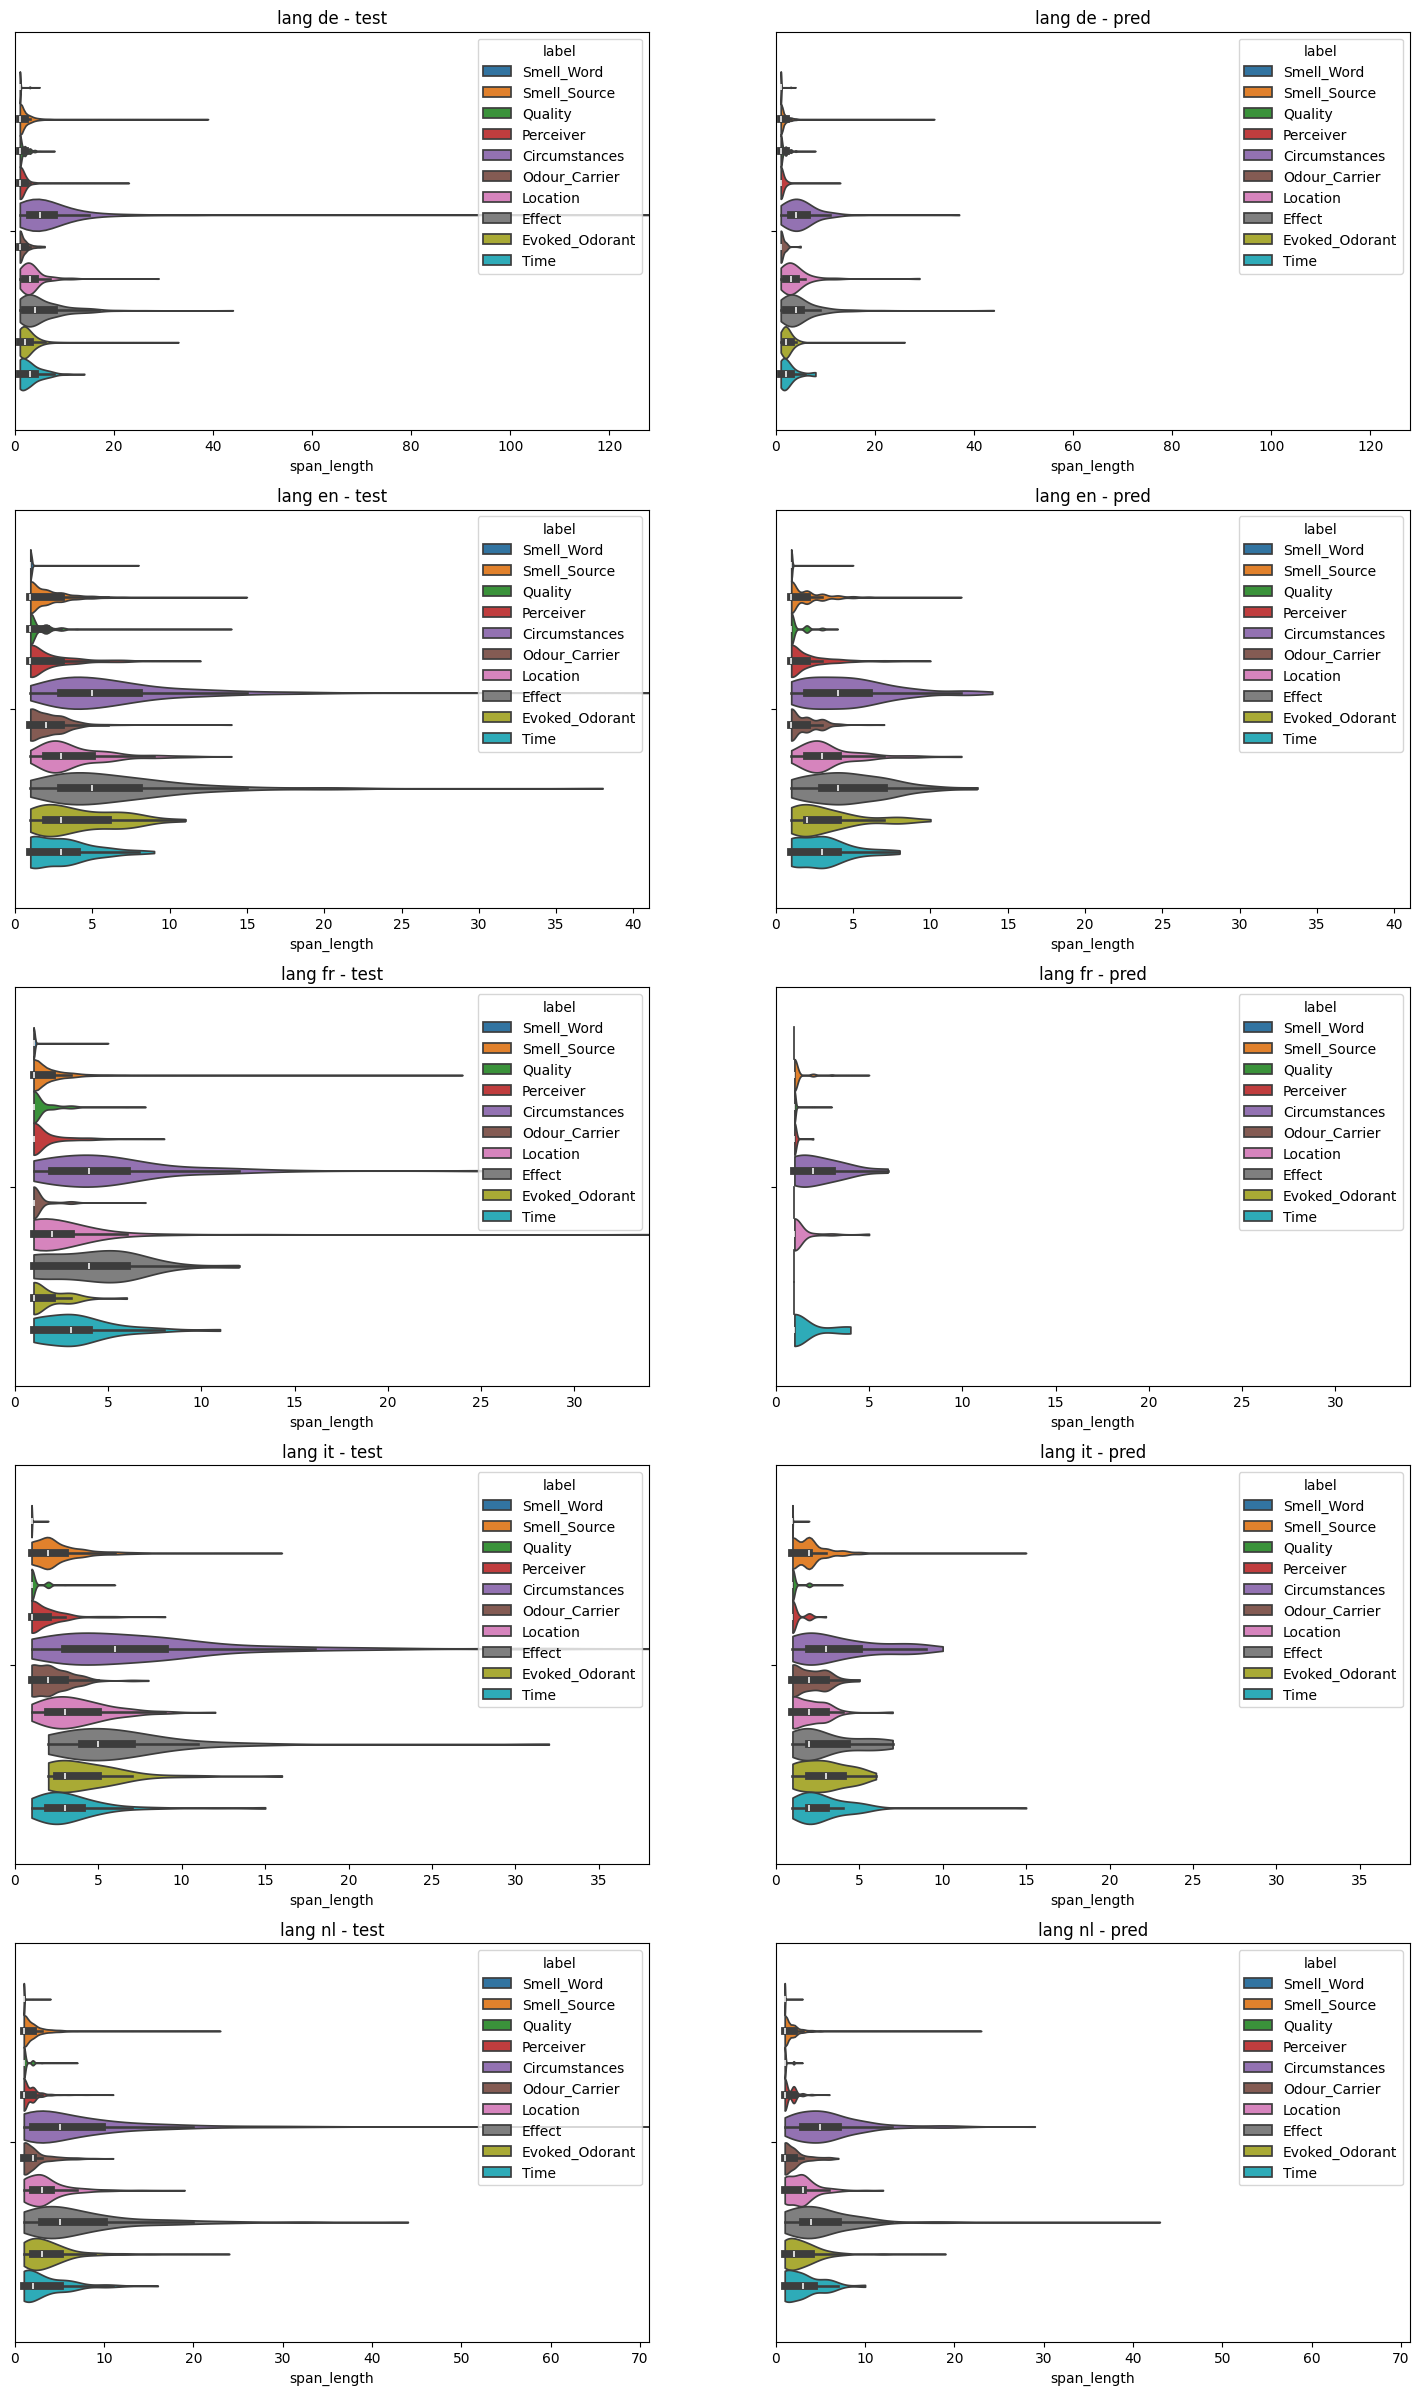

In [146]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(len(languages), 2)

for li, lang in enumerate(languages):
    x_max = test_df[test_df.lang == lang].span_length.max()
    sns.violinplot(test_df[test_df.lang == lang], x='span_length', hue='label', hue_order=labels, ax=ax[li][0], cut=0)
    sns.violinplot(pred_df[pred_df.lang == lang], x='span_length', hue='label', hue_order=labels, ax=ax[li][1], cut=0)
    ax[li][0].set_title(f"lang {lang} - test")
    ax[li][1].set_title(f"lang {lang} - pred")
    ax[li][0].set_xlim((0, x_max))
    ax[li][1].set_xlim((0, x_max))
    


fig.set_size_inches(18, len(languages)*6)

In [213]:
overlap_df[overlap_df.match_type == 'miss_pred']

,test_text_id,test_sent_idx,test_start,test_end,test_text,test_label,pred_text_id,pred_sent_idx,pred_start,pred_end,pred_text,pred_label,match_type,overlap_start,overlap_end,lang,fold,model_type
0,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,3.0,40.0,41.0,Tabac,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,de,0,contemporary
1,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,3.0,1.0,10.0,Wann ſie trocken worden / ſo feuchtet man ſie,Circumstances,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,de,0,contemporary
8,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,4.0,1.0,3.0,Soll er,Circumstances,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,de,0,contemporary
12,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,6.0,86.0,87.0,Gaͤrtlein,Location,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,de,0,contemporary
13,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,6.0,34.0,66.0,habe ich Tabackkraut mit Camillenbluͤhe im Waſ...,Circumstances,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,de,0,contemporary
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1684,textJosephine_DAmboinscheRariteitkamer_al_pote...,2.0,129.0,133.0,Ambra en Ambra Grysea,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,nl,4,historical
1687,textJosephine_DAmboinscheRariteitkamer_al_pote...,4.0,38.0,39.0,zich,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,nl,4,historical
1692,textJosephine_DAmboinscheRariteitkamer_al_pote...,4.0,60.0,68.0,doch in een warm sop gesmol - ten,Circumstances,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,nl,4,historical
1701,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0,14.0,21.0,die door zekere groote vogelen worden gegeeten,Circumstances,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,nl,4,historical


### Qualitative Error Analysis

In [200]:
overlap_df[overlap_df.match_type == 'partial'].to_csv('data/multi/partial_matches.tsv', sep='\t', index=False)

In [148]:
overlap_df

,test_text_id,test_sent_idx,test_start,test_end,test_text,test_label,pred_text_id,pred_sent_idx,pred_start,pred_end,pred_text,pred_label,match_type,overlap_start,overlap_end,lang,fold
0,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,3.0,40.0,41.0,Tabac,Smell_Source,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,de,0
1,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,3.0,1.0,10.0,Wann ſie trocken worden / ſo feuchtet man ſie,Circumstances,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,de,0
2,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,4.0,4.0,5.0,riechen,Smell_Word,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,4.0,4.0,5.0,riechen,Smell_Word,exact,exact,exact,de,0
3,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,4.0,17.0,18.0,wolriechenden,Smell_Word,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,4.0,17.0,18.0,wolriechenden,Smell_Word,exact,exact,exact,de,0
4,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,4.0,11.0,12.0,Anis,Smell_Source,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,4.0,11.0,12.0,Anis,Smell_Source,exact,exact,exact,de,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1698,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0,10.0,11.0,welriekende,Smell_Word,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0,10.0,11.0,welriekende,Smell_Word,exact,exact,exact,nl,4
1699,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0,11.0,12.0,kruiden,Smell_Source,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0,11.0,12.0,kruiden,Smell_Source,exact,exact,exact,nl,4
1700,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0,1.0,5.0,"Deze Maldivische Eilanden ,",Location,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0,1.0,4.0,Deze Maldivische Eilanden,Location,partial,exact,early,nl,4
1701,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0,14.0,21.0,die door zekere groote vogelen worden gegeeten,Circumstances,None,NaN,NaN,NaN,None,None,miss_pred,missed,missed,nl,4


In [214]:
overlap_df.columns
fields = ['text_id', 'sent_idx', 'label']
for field in fields:
    tf = f'test_{field}'
    pf = f'pred_{field}'
    overlap_df[tf] = overlap_df.apply(lambda row: row[tf] if pd.notna(row[tf]) else row[pf], axis=1)
    overlap_df[pf] = overlap_df.apply(lambda row: row[pf] if pd.notna(row[pf]) else row[tf], axis=1)

overlap_df['text_id'] = overlap_df['test_text_id']
overlap_df['sent_idx'] = overlap_df['test_sent_idx']
overlap_df = overlap_df.drop(['test_text_id', 'pred_text_id', 'test_sent_idx', 'pred_sent_idx'], axis=1)

In [215]:
overlap_df

,test_start,test_end,test_text,test_label,pred_start,pred_end,pred_text,pred_label,match_type,overlap_start,overlap_end,lang,fold,model_type,text_id,sent_idx
0,40.0,41.0,Tabac,Smell_Source,NaN,NaN,None,Smell_Source,miss_pred,missed,missed,de,0,contemporary,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,3.0
1,1.0,10.0,Wann ſie trocken worden / ſo feuchtet man ſie,Circumstances,NaN,NaN,None,Circumstances,miss_pred,missed,missed,de,0,contemporary,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,3.0
2,4.0,5.0,riechen,Smell_Word,4.0,5.0,riechen,Smell_Word,exact,exact,exact,de,0,contemporary,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,4.0
3,17.0,18.0,wolriechenden,Smell_Word,17.0,18.0,wolriechenden,Smell_Word,exact,exact,exact,de,0,contemporary,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,4.0
4,11.0,12.0,Anis,Smell_Source,11.0,14.0,Anis / Roſen,Smell_Source,partial,exact,late,de,0,contemporary,HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_...,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1698,10.0,11.0,welriekende,Smell_Word,10.0,11.0,welriekende,Smell_Word,exact,exact,exact,nl,4,historical,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0
1699,11.0,12.0,kruiden,Smell_Source,11.0,12.0,kruiden,Smell_Source,exact,exact,exact,nl,4,historical,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0
1700,1.0,5.0,"Deze Maldivische Eilanden ,",Location,1.0,4.0,Deze Maldivische Eilanden,Location,partial,exact,early,nl,4,historical,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0
1701,14.0,21.0,die door zekere groote vogelen worden gegeeten,Circumstances,NaN,NaN,None,Circumstances,miss_pred,missed,missed,nl,4,historical,textJosephine_DAmboinscheRariteitkamer_am_pote...,7.0


In [210]:
overlap_start_freq = (overlap_df[overlap_df.match_type == 'partial']
    .groupby(['lang', 'test_label', 'model_type'])
    .overlap_start
    .value_counts()
    .unstack()
    .fillna(0.0))


overlap_end_freq = (overlap_df[overlap_df.match_type == 'partial']
    .groupby(['lang', 'test_label', 'model_type'])
    .overlap_end
    .value_counts()
    .unstack()
    .fillna(0.0))

overlap_start_frac = overlap_start_freq.T.div(overlap_start_freq.sum(axis=1)).T
overlap_end_frac = overlap_end_freq.T.div(overlap_end_freq.sum(axis=1)).T
overlap_end_frac.columns = pd.MultiIndex.from_tuples([('End', col) for col in overlap_end_frac.columns], names=['side', 'location'])
overlap_start_frac.columns = pd.MultiIndex.from_tuples([('Start', col) for col in overlap_start_frac.columns], names=['side', 'location'])
pd.concat([overlap_start_frac, overlap_end_frac], axis=1).style.format(precision=2).background_gradient(vmin=0.0, vmax=1.0)



In [217]:
overlap_start_freq = (overlap_df[overlap_df.match_type == 'partial']
    .groupby(['lang', 'model_type'])
    .overlap_start
    .value_counts()
    .unstack()
    .fillna(0.0))


overlap_end_freq = (overlap_df[overlap_df.match_type == 'partial']
    .groupby(['lang', 'model_type'])
    .overlap_end
    .value_counts()
    .unstack()
    .fillna(0.0))

overlap_start_frac = overlap_start_freq.T.div(overlap_start_freq.sum(axis=1)).T
overlap_end_frac = overlap_end_freq.T.div(overlap_end_freq.sum(axis=1)).T
overlap_end_frac.columns = pd.MultiIndex.from_tuples([('End', col) for col in overlap_end_frac.columns], names=['side', 'location'])
overlap_start_frac.columns = pd.MultiIndex.from_tuples([('Start', col) for col in overlap_start_frac.columns], names=['side', 'location'])
pd.concat([overlap_start_frac, overlap_end_frac], axis=1).style.format(precision=2).background_gradient(vmin=0.0, vmax=1.0)



In [163]:
overlap_start = overlap_df.groupby(['lang', 'test_label']).overlap_start.value_counts().unstack().fillna(0.0)
overlap_end = overlap_df.groupby(['lang', 'test_label']).overlap_end.value_counts().unstack().fillna(0.0)
start_max = overlap_start.early.max(), overlap_start.late.max()
end_max = overlap_start.early.max(), overlap_start.late.max()


(np.float64(68.0), np.float64(140.0))

### Within-Sentence Errors

In [122]:
text_ids = list(set(overlap_df[overlap_df.match_type == 'miss_test'].pred_text_id))

In [134]:
text_id = 'HOUSEHOLD_RECIPES_042G_1682_Wolf_Helmhard_von_Hohberg_Georgica_Curiosa__Bd__2__Nürnberg__1682_txtai_potentially_smelly_passages_804'
text_id = text_ids[2]
overlap_df[(overlap_df.text_id == text_id)]

,test_start,test_end,test_text,test_label,pred_start,pred_end,pred_text,pred_label,match_type,overlap_start,overlap_end,lang,fold,text_id,sent_idx
863,11.0,12.0,ſcharffriechenden,Smell_Word,NaN,NaN,None,Smell_Word,miss_pred,missed,missed,de,4,MEDICINE_BOTANY_043G_1690_Pietro_Andrea_Mattio...,2.0
864,14.0,15.0,Holtz,Smell_Source,NaN,NaN,None,Smell_Source,miss_pred,missed,missed,de,4,MEDICINE_BOTANY_043G_1690_Pietro_Andrea_Mattio...,2.0
865,21.0,22.0,riechend,Smell_Word,21.0,22.0,riechend,Smell_Word,exact,exact,exact,de,4,MEDICINE_BOTANY_043G_1690_Pietro_Andrea_Mattio...,3.0
866,3.0,4.0,blaͤtter,Smell_Source,2.0,3.0,laͤngſten,Smell_Source,partial,early,early,de,4,MEDICINE_BOTANY_043G_1690_Pietro_Andrea_Mattio...,3.0
867,20.0,21.0,ſtarck,Quality,20.0,21.0,ſtarck,Quality,exact,exact,exact,de,4,MEDICINE_BOTANY_043G_1690_Pietro_Andrea_Mattio...,3.0
868,NaN,NaN,None,Time,12.0,14.0,im uͤbrigen,Time,miss_test,wrong,wrong,de,4,MEDICINE_BOTANY_043G_1690_Pietro_Andrea_Mattio...,3.0


In [159]:
sent_match_type = overlap_df.groupby(['lang', 'text_id', 'sent_idx', 'test_label']).match_type.value_counts().unstack().fillna(0.0).reset_index()
sent_match_type[(sent_match_type.miss_pred > 0) & (sent_match_type.miss_test > 0)].groupby('lang').test_label.value_counts().unstack()

test_label,Circumstances,Effect,Evoked_Odorant,Location,Odour_Carrier,Perceiver,Quality,Smell_Source,Smell_Word,Time
lang,,,,,,,,,,
de,7.0,7.0,2.0,1.0,1.0,10.0,11.0,140.0,8.0,2.0
en,9.0,5.0,1.0,7.0,7.0,25.0,8.0,57.0,9.0,2.0
fr,1.0,NaN,NaN,3.0,1.0,7.0,20.0,69.0,10.0,2.0
it,5.0,NaN,3.0,6.0,4.0,9.0,12.0,66.0,7.0,NaN
nl,12.0,5.0,NaN,6.0,2.0,8.0,3.0,111.0,20.0,1.0


In [181]:
hallucinated = (sent_match_type[(sent_match_type.miss_pred == 0) & (sent_match_type.miss_test > 0)]
    .groupby('lang')
    .test_label
    .value_counts()
    #.unstack()
    .rename('hallucinated'))

missed = (sent_match_type[(sent_match_type.miss_pred > 0) & (sent_match_type.miss_test == 0)]
    .groupby('lang')
    .test_label
    .value_counts()
    #.unstack()
    .rename('missed'))

misplaced = (sent_match_type[(sent_match_type.miss_pred > 0) & (sent_match_type.miss_test > 0)].groupby('lang')
    .test_label
    .value_counts()
    .rename('misplaced'))
total = overlap_df[overlap_df.test_start.notna()].groupby('lang').test_label.value_counts().rename('total')
misplaced = pd.concat([missed, hallucinated, misplaced, total], axis=1).fillna(0.0).sort_values(['lang', 'total'])
#misplaced.misplaced / misplaced.total

misplaced

missed  hallucinated  misplaced  total
lang test_label                                            
de   Odour_Carrier       87            18        1.0    113
     Time                80            33        2.0    117
     Location           137            41        1.0    178
     Circumstances      129            44        7.0    219
     Evoked_Odorant      84            54        2.0    222
     Perceiver          156            77       10.0    263
     Effect             201            56        7.0    329
     Quality            189           156       11.0    883
     Smell_Source       464           285      140.0   1424
     Smell_Word         221           235        8.0   1457
en   Evoked_Odorant      23            21        1.0     60
     Time                42            26        2.0     99
     Effect              56            47        5.0    119
     Circumstances       70            54        9.0    187
     Location            70            79        7.0    218
     Odour_Carrier       94            66        7.0    238
     Perceiver          100           111       25.0    316
     Quality            108           123        8.0    903
     Smell_Source       209           245       57.0   1198
     Smell_Word         121            92        9.0   1270
fr   Effect              24             3        0.0     31
     Evoked_Odorant      30             6        0.0     42
     Time                33             6        2.0     43
     Circumstances       69             9        1.0     83
     Odour_Carrier       67            15        1.0    107
     Location            72            25        3.0    123
     Perceiver           95            15        7.0    131
     Quality             76            54       20.0    329
     Smell_Word          77            63       10.0    535
     Smell_Source       145            97       69.0    568
it   Evoked_Odorant      26            24        3.0     47
     Effect              43             9        0.0     53
     Time                39            26        0.0     98
     Perceiver           82            42        9.0    120
     Location            81            33        6.0    123
     Circumstances      106            19        5.0    154
     Odour_Carrier      115            23        4.0    165
     Quality            104            91       12.0    573
     Smell_Source       264           140       66.0    794
     Smell_Word         114            75        7.0   1073
nl   Time                81            43        1.0    115
     Evoked_Odorant     100            81        0.0    226
     Location           148            78        6.0    254
     Effect             155            69        5.0    256
     Perceiver          193            98        8.0    318
     Odour_Carrier      222            98        2.0    329
     Circumstances      248           120       12.0    421
     Quality            188           174        3.0    805
     Smell_Word         257           375       20.0   1702
     Smell_Source       612           452      111.0   1853

#### Predicting frame elements without lexical units

- How often does model predict frame elements without predicting lexical units?
- Does ground truth have examples of frame elements without lexical units?


In [195]:
temp = overlap_df.groupby(['lang', 'text_id', 'sent_idx']).test_label.value_counts().unstack().fillna(0.0)
temp = overlap_df.groupby(['lang', 'text_id']).test_label.value_counts().unstack().fillna(0.0)
temp[temp.Smell_Word == 0].sum(axis=1).rename('num_labels').reset_index().sort_values('num_labels')


,lang,text_id,num_labels
4,fr,097F/annotation.tsv,1.0
5,it,/it_hous_1908__60__cucina__Giulia-Turco-Turcat...,2.0
1,fr,073F/annotation.tsv,3.0
0,fr,071F/annotation.tsv,4.0
3,fr,086F/annotation.tsv,7.0
2,fr,078F/annotation.tsv,8.0


In [174]:
overlap_df.groupby('overlap_start').overlap_end.value_counts().unstack()

overlap_end,early,exact,late,missed,wrong
overlap_start,,,,,
early,3.0,8.0,2.0,NaN,NaN
exact,28.0,322.0,6.0,NaN,NaN
late,5.0,27.0,2.0,NaN,NaN
missed,NaN,NaN,NaN,229.0,NaN
wrong,NaN,NaN,NaN,NaN,201.0


## Evaluation

In [16]:
%reload_ext autoreload
%autoreload 2



In [17]:
import pandas as pd

from hist_smell.evaluation.near_misses import read_pred_file
from hist_smell.evaluation.near_misses import tokens_to_spans

from hist_smell.evaluation.near_misses import find_overlapping_spans
from hist_smell.evaluation.near_misses import make_overlapping_spans_dataframe
from hist_smell.evaluation.near_misses import score_strict_lenient


In [18]:
multi_test_file = 'test-files-mt-all-lang/out-fold-smell-en/folds_2_test.tsv'
multi_pred_file = 'multitask/predictions-mt/predictions-en/2_prediction.tsv'
pred_tokens = list(read_pred_file(multi_pred_file))
test_tokens = list(read_pred_file(multi_test_file))

pred_spans = tokens_to_spans(pred_tokens)
test_spans = tokens_to_spans(test_tokens)

test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
pred_df = pd.DataFrame([ps.__dict__ for ps in pred_spans])
test_freq = test_df.label.value_counts().rename('test_freq')
pred_freq = pred_df.label.value_counts().rename('pred_freq')

overlapping_spans = find_overlapping_spans(test_spans, pred_spans)
print(len(overlapping_spans), len(test_spans), len(pred_spans))
overlap_df = make_overlapping_spans_dataframe(overlapping_spans)


fold_score = score_strict_lenient(overlap_df, test_freq, pred_freq)
fold_score

1096 868 833


,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1
Smell_Word,0.927039,0.874494,0.900000,0.931330,0.878543,0.904167
Smell_Source,0.507317,0.460177,0.482599,0.634146,0.575221,0.603248
Quality,0.735135,0.751381,0.743169,0.843243,0.861878,0.852459
Perceiver,0.327586,0.327586,0.327586,0.465517,0.465517,0.465517
Odour_Carrier,0.522727,0.479167,0.500000,0.636364,0.583333,0.608696
Circumstances,0.342857,0.352941,0.347826,0.628571,0.647059,0.637681
Location,0.428571,0.454545,0.441176,0.600000,0.636364,0.617647
Time,0.500000,0.368421,0.424242,0.714286,0.526316,0.606061
Effect,0.210526,0.266667,0.235294,0.315789,0.400000,0.352941
Evoked_Odorant,0.400000,0.285714,0.333333,0.600000,0.428571,0.500000


### Eval historical multitask

In [1]:
%reload_ext autoreload
%autoreload 2



In [2]:
import pandas as pd

from hist_smell.evaluation.near_misses import read_pred_file
from hist_smell.evaluation.near_misses import tokens_to_spans

from hist_smell.evaluation.near_misses import find_overlapping_spans
from hist_smell.evaluation.near_misses import make_overlapping_spans_dataframe
from hist_smell.evaluation.near_misses import score_strict_lenient


W0223 14:23:07.769000 49004 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.
/opt/homebrew/lib/python3.11/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /opt/homebrew/lib/python3.11/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [3]:
hist_multi_folds_score = []
languages = ['de', 'en', 'fr', 'it', 'nl']
for lang in languages:
    for fold in range(0, 5):
        multi_test_file = f'test-files-mt-all-lang/out-fold-smell-{lang}/folds_{fold}_test.tsv'
        multi_pred_file = f'multitask/predictions-mt/predictions-{lang}/{fold}_prediction.tsv'
        pred_tokens = list(read_pred_file(multi_pred_file))
        test_tokens = list(read_pred_file(multi_test_file))
        
        pred_spans = tokens_to_spans(pred_tokens)
        test_spans = tokens_to_spans(test_tokens)
        
        test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
        pred_df = pd.DataFrame([ps.__dict__ for ps in pred_spans])
        test_freq = test_df.label.value_counts().rename('test_freq')
        pred_freq = pred_df.label.value_counts().rename('pred_freq')
        
        overlapping_spans = find_overlapping_spans(test_spans, pred_spans)
        print(lang, fold, len(overlapping_spans), len(test_spans), len(pred_spans))
        overlap_df = make_overlapping_spans_dataframe(overlapping_spans)
        
        fold_score = score_strict_lenient(overlap_df, test_freq, pred_freq)
        fold_score['fold'] = fold
        fold_score['lang'] = lang
        hist_multi_folds_score.append(fold_score)

hist_multi_folds_score = pd.concat(hist_multi_folds_score)
hist_multi_folds_score = hist_multi_folds_score.reset_index().rename(columns={'index': 'layer'})
hist_multi_folds_score.sort_index()


de 0 1256 973 847
de 1 1277 1037 754
de 2 1525 1023 1108
de 3 1241 1055 751
de 4 1262 1027 774
en 0 815 607 646
en 1 1455 1119 1102
en 2 1096 868 833
en 3 1229 953 969
en 4 1282 969 1008
fr 0 252 166 143
fr 1 735 564 381
fr 2 469 376 271
fr 3 494 394 286
fr 4 627 448 406
it 0 526 427 347
it 1 1093 836 730
it 2 802 670 517
it 3 693 570 446
it 4 766 647 492
nl 0 1699 1205 1135
nl 1 1584 1219 1034
nl 2 1665 1232 1084
nl 3 1655 1255 1115
nl 4 1703 1287 1054


,layer,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1,fold,lang
0,Smell_Word,0.860806,0.848375,0.854545,0.875458,0.862816,0.869091,0,de
1,Smell_Source,0.444915,0.394737,0.418327,0.601695,0.533835,0.565737,0,de
2,Quality,0.575581,0.626582,0.600000,0.779070,0.848101,0.812121,0,de
3,Effect,0.235294,0.135593,0.172043,0.529412,0.305085,0.387097,0,de
4,Evoked_Odorant,0.371429,0.288889,0.325000,0.628571,0.488889,0.550000,0,de
...,...,...,...,...,...,...,...,...,...
320,Location,0.227273,0.151515,0.181818,0.500000,0.333333,0.400000,4,nl
321,Time,0.444444,0.129032,0.200000,0.444444,0.129032,0.200000,4,nl
322,Overall,0.525617,0.430458,0.473302,0.629981,0.515929,0.567279,4,nl
323,macro_avg,0.391942,0.284892,0.321160,0.518593,0.372379,0.423834,4,nl


### Eval contemporary multi

In [4]:
cont_multi_folds_score = []
languages = ['de', 'en', 'fr', 'it', 'nl']
for lang in languages:
    for fold in range(0, 5):
        multi_test_file = f'test-files-mt-all-lang/out-fold-smell-{lang}/folds_{fold}_test.tsv'
        multi_pred_file = f'multitask/predictions-mt/predictions-contemporary/predictions-{lang}-contemporary/{fold}_prediction-contemporary.tsv'
        pred_tokens = list(read_pred_file(multi_pred_file))
        test_tokens = list(read_pred_file(multi_test_file))
        
        pred_spans = tokens_to_spans(pred_tokens)
        test_spans = tokens_to_spans(test_tokens)
        
        test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
        pred_df = pd.DataFrame([ps.__dict__ for ps in pred_spans])
        test_freq = test_df.label.value_counts().rename('test_freq')
        pred_freq = pred_df.label.value_counts().rename('pred_freq')
        
        overlapping_spans = find_overlapping_spans(test_spans, pred_spans)
        print(lang, fold, len(overlapping_spans), len(test_spans), len(pred_spans))
        overlap_df = make_overlapping_spans_dataframe(overlapping_spans)
        
        fold_score = score_strict_lenient(overlap_df, test_freq, pred_freq)
        fold_score['fold'] = fold
        fold_score['lang'] = lang
        cont_multi_folds_score.append(fold_score)

cont_multi_folds_score = pd.concat(cont_multi_folds_score)
cont_multi_folds_score = cont_multi_folds_score.reset_index().rename(columns={'index': 'layer'})
cont_multi_folds_score.sort_index()


de 0 1263 973 857
de 1 1321 1037 798
de 2 1479 1023 1032
de 3 1225 1055 689
de 4 1305 1027 815
en 0 810 607 618
en 1 1510 1119 1109
en 2 1080 868 800
en 3 1240 953 946
en 4 1242 969 934
fr 0 260 166 165
fr 1 696 564 402
fr 2 496 376 341
fr 3 622 394 468
fr 4 563 448 273
it 0 596 427 462
it 1 1022 836 699
it 2 812 670 591
it 3 750 570 560
it 4 901 647 707
nl 0 1573 1205 926
nl 1 1635 1219 1029
nl 2 1648 1232 1016
nl 3 1683 1255 1086
nl 4 1613 1287 889


,layer,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1,fold,lang
0,Smell_Word,0.845878,0.851986,0.848921,0.860215,0.866426,0.863309,0,de
1,Smell_Source,0.420833,0.379699,0.399209,0.583333,0.526316,0.553360,0,de
2,Quality,0.521277,0.620253,0.566474,0.744681,0.886076,0.809249,0,de
3,Effect,0.227273,0.084746,0.123457,0.545455,0.203390,0.296296,0,de
4,Evoked_Odorant,0.304348,0.311111,0.307692,0.695652,0.711111,0.703297,0,de
...,...,...,...,...,...,...,...,...,...
320,Location,0.357143,0.151515,0.212766,0.500000,0.212121,0.297872,4,nl
321,Time,0.428571,0.096774,0.157895,0.428571,0.096774,0.157895,4,nl
322,Overall,0.543307,0.375291,0.443934,0.653543,0.451437,0.534007,4,nl
323,macro_avg,0.384125,0.247032,0.289140,0.518490,0.321959,0.383296,4,nl


### Eval historical single-task

In [5]:
lang_code_map = {
    'dutch': 'nl', 
    'english': 'en', 
    'french': 'fr', 
    'german': 'de', 
    'italian': 'it'
}

code_lang_map = {code: lang for lang, code in lang_code_map.items()}
code_lang_map

{'nl': 'dutch',
 'en': 'english',
 'fr': 'french',
 'de': 'german',
 'it': 'italian'}

In [28]:
import copy

hist_single_folds_score = []
languages = ['de', 'en', 'fr', 'it', 'nl']
for lang in languages:
    for fold in range(0, 5):
        single_pred_file = f'single_task/test-pred-all-lang-st/{code_lang_map[lang]}-st/{lang}-folds_{fold}_pred.tsv'
        tokens = list(read_pred_file(single_pred_file, use_sent_token=False))
        
        test_tokens, pred_tokens = [], []
        for token in tokens:
            test_token = copy.deepcopy(token)
            test_token.labels.pop(1)
            del test_token.col[5]
            test_tokens.append(test_token)
            
        for token in tokens:
            pred_token = copy.deepcopy(token)
            pred_token.labels.pop(0)
            pred_token.col[4] = pred_token.col[5]
            del pred_token.col[5]
            pred_tokens.append(pred_token)
            
            
        pred_spans = tokens_to_spans(pred_tokens)
        test_spans = tokens_to_spans(test_tokens)
        
        test_df = pd.DataFrame([ts.__dict__ for ts in test_spans])
        pred_df = pd.DataFrame([ps.__dict__ for ps in pred_spans])
        
        test_freq = test_df.label.value_counts().rename('test_freq')
        pred_freq = pred_df.label.value_counts().rename('pred_freq')
        
        overlapping_spans = find_overlapping_spans(test_spans, pred_spans)
        print(lang, fold, len(overlapping_spans), len(test_spans), len(pred_spans))
        overlap_df = make_overlapping_spans_dataframe(overlapping_spans)
        
        fold_score = score_strict_lenient(overlap_df, test_freq, pred_freq)
        fold_score['fold'] = fold
        fold_score['lang'] = lang
        hist_single_folds_score.append(fold_score)
        

hist_single_folds_score = pd.concat(hist_single_folds_score)
hist_single_folds_score = hist_single_folds_score.reset_index().rename(columns={'index': 'layer'})
hist_single_folds_score.sort_index()


de 0 1345 968 958
de 1 1398 948 1023
de 2 1343 987 971
de 3 1963 1149 1558
de 4 1439 1008 1060
en 0 1153 845 814
en 1 1540 1079 1146
en 2 1409 966 1098
en 3 1357 942 1058
en 4 1624 1182 1178
fr 0 474 344 303
fr 1 707 488 436
fr 2 759 555 461
fr 3 643 450 441
fr 4 757 464 561
it 0 613 479 367
it 1 1039 805 644
it 2 682 549 391
it 3 776 587 524
it 4 930 764 597
nl 0 1697 1305 1021
nl 1 1543 1207 884
nl 2 1450 1191 705
nl 3 1445 1244 656
nl 4 1338 1247 451


,layer,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1,fold,lang
0,Smell_Word,0.867424,0.874046,0.870722,0.897727,0.904580,0.901141,0,de
1,Smell_Source,0.339869,0.403101,0.368794,0.578431,0.686047,0.627660,0,de
2,Quality,0.546961,0.611111,0.577259,0.712707,0.796296,0.752187,0,de
3,Effect,0.089286,0.069444,0.078125,0.285714,0.222222,0.250000,0,de
4,Circumstances,0.162791,0.148936,0.155556,0.488372,0.446809,0.466667,0,de
...,...,...,...,...,...,...,...,...,...
320,Location,NaN,0.000000,NaN,NaN,0.000000,NaN,4,nl
321,Time,NaN,0.000000,NaN,NaN,0.000000,NaN,4,nl
322,Overall,0.762749,0.275862,0.405183,0.815965,0.295108,0.433451,4,nl
323,macro_avg,0.610247,0.127360,0.340641,0.902508,0.141852,0.384167,4,nl


In [31]:
hist_multi_folds_score['task_type'] = 'multitask'
hist_multi_folds_score['model_type'] = 'hist'

cont_multi_folds_score['task_type'] = 'multitask'
cont_multi_folds_score['model_type'] = 'cont'

hist_single_folds_score['task_type'] = 'multiclass'
hist_single_folds_score['model_type'] = 'hist'

scores = pd.concat([cont_multi_folds_score, hist_multi_folds_score, hist_single_folds_score])

In [91]:
eval_cols = ['exact_prec', 'exact_rec', 'exact_f1', 'lenient_prec', 'lenient_rec', 'lenient_f1']
exact_cols = ['exact_prec', 'exact_rec', 'exact_f1']
lenient_cols = ['lenient_prec', 'lenient_rec', 'lenient_f1']
temp = scores.groupby(['lang', 'task_type', 'model_type', 'layer'])[eval_cols].mean().reset_index()


In [117]:
temp = temp[temp.task_type == 'multitask']

In [118]:
temp

,lang,task_type,model_type,layer,exact_prec,exact_rec,exact_f1,lenient_prec,lenient_rec,lenient_f1
13,de,multitask,cont,Circumstances,0.239758,0.112023,0.142198,0.532396,0.243063,0.311813
14,de,multitask,cont,Effect,0.206819,0.066190,0.099928,0.472444,0.150774,0.227558
15,de,multitask,cont,Evoked_Odorant,0.350380,0.297354,0.317127,0.706104,0.607297,0.644338
16,de,multitask,cont,Location,0.228205,0.088882,0.126005,0.329641,0.131701,0.185294
17,de,multitask,cont,Odour_Carrier,0.313492,0.130292,0.159681,0.313492,0.130292,0.159681
...,...,...,...,...,...,...,...,...,...,...
190,nl,multitask,hist,Smell_Source,0.400914,0.348451,0.371605,0.571005,0.497314,0.529849
191,nl,multitask,hist,Smell_Word,0.746067,0.808021,0.775516,0.762899,0.826460,0.793111
192,nl,multitask,hist,Time,0.290835,0.181695,0.215510,0.346129,0.227258,0.265291
193,nl,multitask,hist,macro_avg,0.385893,0.317363,0.340710,0.504764,0.408724,0.442309


In [126]:
temp
cont = temp[temp.model_type == 'cont'].sort_values(['layer', 'lang', 'task_type']).drop(['model_type', 'task_type'], axis=1)
hist = temp[temp.model_type == 'hist'].sort_values(['layer', 'lang', 'task_type']).drop(['model_type', 'task_type'], axis=1)
cont_exact = cont[exact_cols]
cont_lenient = cont[lenient_cols]
hist_exact = hist[exact_cols]
hist_lenient = hist[lenient_cols]
print(cont_exact.shape, cont_lenient.shape, hist_exact.shape, hist_lenient.shape)
layer_lang = hist[['layer', 'lang']].reset_index().drop('index', axis=1)

cont_exact = cont_exact.rename(columns={col: col.split('_')[-1] for col in cont_exact.columns})
cont_lenient = cont_lenient.rename(columns={col: col.split('_')[-1] for col in cont_lenient.columns})
hist_exact = hist_exact.rename(columns={col: col.split('_')[-1] for col in hist_exact.columns})
hist_lenient = hist_lenient.rename(columns={col: col.split('_')[-1] for col in hist_lenient.columns})
print(cont_exact.shape, cont_lenient.shape, hist_exact.shape, hist_lenient.shape)
cont_exact = pd.concat({'Contemporary': cont_exact}, names=['model_type'], axis=1).reset_index().drop('index', axis=1)
cont_lenient = pd.concat({'Contemporary': cont_lenient}, names=['model_type'], axis=1).reset_index().drop('index', axis=1)
hist_exact = pd.concat({'Historical': hist_exact}, names=['model_type'], axis=1).reset_index().drop('index', axis=1)
hist_lenient = pd.concat({'Historical': hist_lenient}, names=['model_type'], axis=1).reset_index().drop('index', axis=1)
cont_exact = pd.concat({'Strict': cont_exact}, names=['eval_type'], axis=1)
hist_exact = pd.concat({'Strict': hist_exact}, names=['eval_type'], axis=1)
cont_lenient = pd.concat({'Lenient': cont_lenient}, names=['eval_type'], axis=1)
hist_lenient = pd.concat({'Lenient': hist_lenient}, names=['eval_type'], axis=1)

table=  pd.concat([layer_lang, cont_exact, hist_exact, cont_lenient, hist_lenient], axis=1).style.format(precision=3).hide(axis=0).to_latex()
#cont_exact.shape, cont_lenient.shape, hist_exact.shape, hist_lenient.shape
#layer_lang
print(table)

(65, 3) (65, 3) (65, 3) (65, 3)
(65, 3) (65, 3) (65, 3) (65, 3)
\begin{tabular}{llrrrrrrrrrrrr}
layer & lang & ('Strict', 'Contemporary', 'prec') & ('Strict', 'Contemporary', 'rec') & ('Strict', 'Contemporary', 'f1') & ('Strict', 'Historical', 'prec') & ('Strict', 'Historical', 'rec') & ('Strict', 'Historical', 'f1') & ('Lenient', 'Contemporary', 'prec') & ('Lenient', 'Contemporary', 'rec') & ('Lenient', 'Contemporary', 'f1') & ('Lenient', 'Historical', 'prec') & ('Lenient', 'Historical', 'rec') & ('Lenient', 'Historical', 'f1') \\
Circumstances & de & 0.240 & 0.112 & 0.142 & 0.262 & 0.143 & 0.177 & 0.532 & 0.243 & 0.312 & 0.540 & 0.301 & 0.372 \\
Circumstances & en & 0.363 & 0.283 & 0.311 & 0.328 & 0.318 & 0.321 & 0.554 & 0.449 & 0.486 & 0.572 & 0.562 & 0.564 \\
Circumstances & fr & 0.040 & 0.057 & 0.041 & 0.028 & 0.017 & 0.024 & 0.494 & 0.428 & 0.368 & 0.156 & 0.057 & 0.093 \\
Circumstances & it & 0.203 & 0.178 & 0.177 & 0.278 & 0.123 & 0.164 & 0.505 & 0.495 & 0.470 & 0.534 & 0.222 &

/var/folders/xk/pp9n20396sqccydf42gn2rmr0000gn/T/ipykernel_49004/1425062204.py:16: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  cont_exact = pd.concat({'Contemporary': cont_exact}, names=['model_type'], axis=1).reset_index().drop('index', axis=1)
/var/folders/xk/pp9n20396sqccydf42gn2rmr0000gn/T/ipykernel_49004/1425062204.py:17: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  cont_lenient = pd.concat({'Contemporary': cont_lenient}, names=['model_type'], axis=1).reset_index().drop('index', axis=1)
/var/folders/xk/pp9n20396sqccydf42gn2rmr0000gn/T/ipykernel_49004/1425062204.py:18: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  hist_exact = pd.concat({'Historical': hist_exact}, names=['model_type'], axis=1).reset_index().drop('index', axis=1)
/var/folders/xk/pp9n20396sqccydf42gn2rmr0000gn/T/ipykern